# Student Segmentation and Personalized Course Recommendation System for EduPro

In [ ]:
#Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Clustering
from sklearn.cluster import KMeans,AgglomerativeClustering

# Validation,Davis-Bouldin Score and Calinski-Harabasz Score
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score

# Recommendation
from sklearn.metrics.pairwise import cosine_similarity

#PCA for Cluster Visualization
from sklearn.decomposition import PCA

**Load Dataset**

In [ ]:
#Users
df = pd.read_csv("/content/EduPro Online Platform.xlsx - Users.csv")
#Teachers
te = pd.read_csv("/content/EduPro Online Platform.xlsx - Teachers.csv")
#Courses
co = pd.read_csv("/content/EduPro Online Platform.xlsx - Courses.csv")
#Transactions
tr = pd.read_csv("/content/EduPro Online Platform.xlsx - Transactions.csv")

**Data Cleaning**

In [ ]:
df.drop_duplicates(inplace=True)
co.drop_duplicates(inplace=True)
te.drop_duplicates(inplace=True)
tr.drop_duplicates(inplace=True)
tr["TransactionDate"] = pd.to_datetime(
    tr["TransactionDate"],dayfirst=True
)

In [ ]:
print(df.columns)
print(te.columns)
print(co.columns)
print(tr.columns)

Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='object')
Index(['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise',
       'YearsOfExperience', 'TeacherRating'],
      dtype='object')
Index(['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating'],
      dtype='object')
Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID'],
      dtype='object')


**Merge Datasets**

In [ ]:
student_data = tr.merge(df,on="UserID",how="left")
student_data = student_data.merge(co,on="CourseID",how="left")
print(student_data.head())

  TransactionID  UserID CourseID TransactionDate  Amount  PaymentMethod  \
0       TT00001  U00003  CR00016      2025-10-25     0.0         PayPal   
1       TT00002  U00003  CR00037      2025-01-13     0.0         PayPal   
2       TT00003  U00003  CR00019      2025-03-28     0.0  Bank Transfer   
3       TT00004  U00004  CR00048      2025-06-02     0.0  Bank Transfer   
4       TT00005  U00004  CR00060      2025-08-10     0.0         PayPal   

  TeacherID        UserName  Age  Gender                             Email  \
0   TC00040  morrisonamanda   33  Female               ganderson@yahoo.com   
1   TC00040  morrisonamanda   33  Female               ganderson@yahoo.com   
2   TC00040  morrisonamanda   33  Female               ganderson@yahoo.com   
3   TC00040       fthornton   23  Female  christensencatherine@outlook.com   
4   TC00042       fthornton   23  Female  christensencatherine@outlook.com   

          CourseName           CourseCategory CourseType   CourseLevel  \
0  Dig

**Feature Engineering**

**Engineering Features**

In [ ]:
# Total Courses Enrolled

total_courses = (
    student_data.groupby("UserID")["CourseID"]
    .count()
    .reset_index()
)

total_courses.columns = [
    "UserID",
    "TotalCoursesEnrolled"
]

print(total_courses.head())

# Average courses per category

total_courses = student_data.groupby("UserID")["CourseID"].count()

unique_categories = student_data.groupby("UserID")["CourseCategory"].nunique()

avg_courses_per_category = (
    total_courses / unique_categories
).reset_index(name="AvgCoursesPerCategory")

print(avg_courses_per_category.head())

# Enrollment Frequency

enrollment_frequency = (
    student_data.groupby("UserID")
    .size()
    .reset_index(name="EnrollmentFrequency")
)

print(enrollment_frequency.head())

   UserID  TotalCoursesEnrolled
0  U00001                     1
1  U00002                     1
2  U00003                    11
3  U00004                    13
4  U00005                     2
   UserID  AvgCoursesPerCategory
0  U00001               1.000000
1  U00002               1.000000
2  U00003               1.571429
3  U00004               1.625000
4  U00005               1.000000
   UserID  EnrollmentFrequency
0  U00001                    1
1  U00002                    1
2  U00003                   11
3  U00004                   13
4  U00005                    2


**Preference Features**

In [ ]:
# Preferred Category

preferred_category = (
    student_data.groupby(["UserID","CourseCategory"])
    .size()
    .reset_index(name="count")
)

preferred_category = preferred_category.loc[
    preferred_category.groupby("UserID")["count"].idxmax()
]

preferred_category = preferred_category[
    ["UserID","CourseCategory"]
]

# Preferred Level

preferred_level = (
    student_data.groupby(["UserID","CourseLevel"])
    .size()
    .reset_index(name="count")
)

preferred_level = preferred_level.loc[
    preferred_level.groupby("UserID")["count"].idxmax()
]

preferred_level = preferred_level[
    ["UserID","CourseLevel"]
]

# Average Course Rating Enrolled

avg_rating = student_data.groupby(
    "UserID"
)["CourseRating"].mean()

**Behavioral Features**

In [ ]:
# Average Spending

avg_spending = student_data.groupby(
    "UserID"
)["Amount"].mean()

# Diversity Score

diversity_score = student_data.groupby(
    "UserID"
)["CourseCategory"].nunique()

#Learning Depth Index(Beginners Vs Advanced ratio)

# Count beginner courses
beginner_count = (
    student_data[student_data["CourseLevel"] == "Beginner"]
    .groupby("UserID")
    .size()
)

# Count advanced courses
advanced_count = (
    student_data[student_data["CourseLevel"] == "Advanced"]
    .groupby("UserID")
    .size()
)

# Combine
learning_depth = pd.concat(
    [beginner_count, advanced_count],
    axis=1
).fillna(0)

learning_depth.columns = [
    "BeginnerCount",
    "AdvancedCount"
]

# Learning Depth Index
learning_depth["LearningDepthIndex"] = (
    (learning_depth["AdvancedCount"] + 1)
    /
    (learning_depth["BeginnerCount"] + 1)
)
learning_depth=learning_depth.reset_index()
print(learning_depth.head())

   UserID  BeginnerCount  AdvancedCount  LearningDepthIndex
0  U00002            1.0            0.0                 0.5
1  U00003            4.0            4.0                 1.0
2  U00004            4.0            3.0                 0.8
3  U00005            1.0            1.0                 1.0
4  U00010            1.0            0.0                 0.5


**Learner-Level Aggregation**

   UserID  TotalCourses  AvgSpending  DiversityScore  AvgRating  \
0  U00001             1   394.260000               1   1.350000   
1  U00002             1     0.000000               1   2.880000   
2  U00003            11    55.816364               7   2.889091   
3  U00004            13    75.542308               8   3.451538   
4  U00005             2   173.355000               2   2.055000   

   EnrollmentFrequency        UserName  Age  Gender  \
0                    1    wilsonjordan   15    Male   
1                    1        angela22   29  Female   
2                   11  morrisonamanda   33  Female   
3                   13       fthornton   23  Female   
4                    2  fostergeoffrey   21    Male   

                              Email     CourseCategory   CourseLevel  \
0            patricia27@hotmail.com      Cybersecurity  Intermediate   
1             hallrandy@hotmail.com        Programming      Beginner   
2               ganderson@yahoo.com          Marke

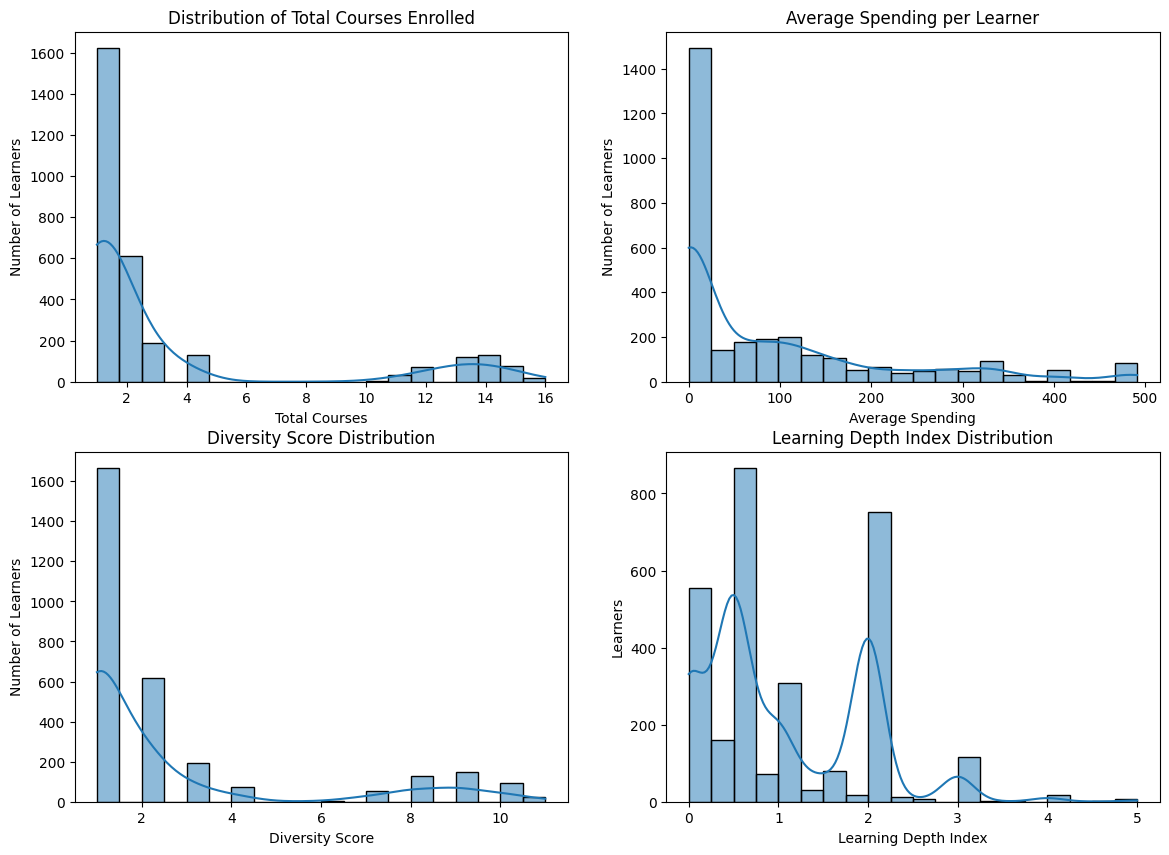

In [ ]:
#Create Learner Profile Combining Demographics and Behavior

learner_profile = pd.DataFrame()

learner_profile["TotalCourses"] = total_courses
learner_profile["AvgSpending"] = avg_spending
learner_profile["DiversityScore"] = diversity_score
learner_profile["AvgRating"] = avg_rating

learner_profile.reset_index(inplace=True)

learner_profile = learner_profile.merge(
    enrollment_frequency,
    on="UserID",
    how="left"
)

learner_profile = learner_profile.merge(
    df,
    on="UserID",
    how="left"
)

learner_profile = learner_profile.merge(
    preferred_category,
    on="UserID",
    how="left"
)

learner_profile = learner_profile.merge(
    preferred_level,
    on="UserID",
    how="left"
)

learner_profile = learner_profile.merge(
    learning_depth[["UserID", "LearningDepthIndex"]],
    on="UserID",
    how="left"
)
learner_profile["LearningDepthIndex"] = (
    learner_profile["LearningDepthIndex"]
    .fillna(0)
)
print(learner_profile.head())
plt.figure(figsize=(14,10))
#Total courses Enrolled
plt.subplot(2,2,1)
sns.histplot(
    learner_profile["TotalCourses"],
    bins=20,
    kde=True
)
plt.title("Distribution of Total Courses Enrolled")
plt.xlabel("Total Courses")
plt.ylabel("Number of Learners")
#Average Spending Distribution
plt.subplot(2,2,2)
sns.histplot(
    learner_profile["AvgSpending"],
    bins=20,
    kde=True
)
plt.title("Average Spending per Learner")
plt.xlabel("Average Spending")
plt.ylabel("Number of Learners")
#Diversity Score
plt.subplot(2,2,3)
sns.histplot(
    learner_profile["DiversityScore"],
    bins=20,
    kde=True
)
plt.title("Diversity Score Distribution")
plt.xlabel("Diversity Score")
plt.ylabel("Number of Learners")
#Learning Depth Index Distribution
plt.subplot(2,2,4)
sns.histplot(
    learner_profile["LearningDepthIndex"],
    bins=20,
    kde=True
)
plt.title("Learning Depth Index Distribution")
plt.xlabel("Learning Depth Index")
plt.ylabel("Learners")
plt.show()

**Data Processing**

**Encode categorical variables**

In [ ]:
le_gender = LabelEncoder()
le_category = LabelEncoder()
le_level = LabelEncoder()
learner_profile["Gender"] = le_gender.fit_transform(
    learner_profile["Gender"]
)

learner_profile["CourseCategory"] = le_category.fit_transform(
    learner_profile["CourseCategory"]
)
learner_profile["CourseLevel"] = le_level.fit_transform(
    learner_profile["CourseLevel"]
)
print("Categorical Encoding Completed")

Categorical Encoding Completed


**Reduce noise from sparse enrollments**

In [ ]:
# Remove users with fewer than 2 enrollments

learner_profile = learner_profile[
    learner_profile["TotalCourses"] >= 2
]
print("Filtered Learners:", learner_profile.shape)

Filtered Learners: (1380, 13)


**Normalize numerical features**

In [ ]:
features = [
    "Age",
    "Gender",
    "TotalCourses",
    "AvgSpending",
    "EnrollmentFrequency",
    "DiversityScore",
    "AvgRating",
    "LearningDepthIndex",
    "CourseCategory",
    "CourseLevel"
]
X = learner_profile[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Normalization Completed")
print(pd.DataFrame(X_scaled).head())

Normalization Completed
          0         1         2         3         4         5         6  \
0  1.356319 -0.958818  0.943622 -0.394703  0.943622  0.820491 -0.398786   
1 -0.319048 -0.958818  1.326621 -0.153975  1.326621  1.139622  0.487611   
2 -0.654121  1.042951 -0.779876  1.039693 -0.779876 -0.775165 -1.713282   
3  1.523855 -0.958818 -0.779876  0.913447 -0.779876 -0.775165  0.036037   
4 -1.659341 -0.958818 -0.779876  0.752054 -0.779876 -0.775165  0.099075   

          7         8         9  
0 -0.229224  1.518711 -0.884647  
1 -0.450032  0.531823  1.938042  
2 -0.229224  1.847674 -0.884647  
3 -0.781244 -1.112991  0.526697  
4 -0.229224 -0.126102 -0.884647  


**Learner Segmentation (Clustering)**

**Elbow Method**

In [ ]:
import importlib
importlib.reload(plt)
print(type(plt.plot))

<class 'function'>


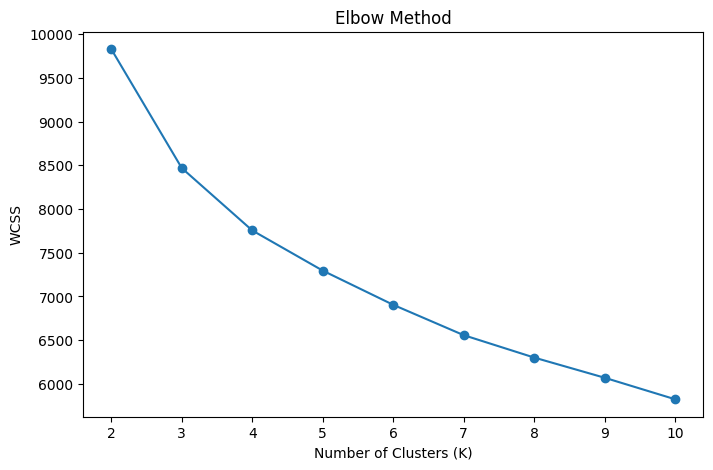

In [ ]:
wcss = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

**Silhouette Method**

In [ ]:
silhouette_scores = []
for k in range(2,11):
  kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled,labels)
  silhouette_scores.append(score)
  print(
        f"K={k}  Silhouette Score={score:.4f}"
    )

K=2  Silhouette Score=0.2863
K=3  Silhouette Score=0.2348
K=4  Silhouette Score=0.2230
K=5  Silhouette Score=0.1759
K=6  Silhouette Score=0.1610
K=7  Silhouette Score=0.1587
K=8  Silhouette Score=0.1626
K=9  Silhouette Score=0.1650
K=10  Silhouette Score=0.1586


**Plot Scores**

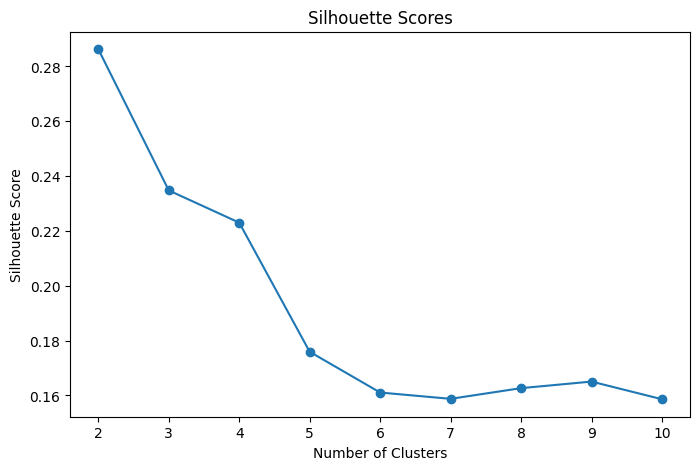

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

**Final K-Means Clustering**

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

learner_profile["Cluster"] = (
    kmeans.fit_predict(X_scaled)
)

print(
    learner_profile["Cluster"]
    .value_counts()
)

Cluster
2    454
0    389
1    276
3    261
Name: count, dtype: int64


**Hierarchical Clustering (validation)**

In [ ]:
#Train Model
hc = AgglomerativeClustering(
    n_clusters=4
)

hc_labels = hc.fit_predict(
    X_scaled
)
#Silhouette Score
hc_score = silhouette_score(
    X_scaled,
    hc_labels
)

print(
    "Hierarchical Silhouette Score:",
    round(hc_score,4)
)

Hierarchical Silhouette Score: 0.2037


**Compare K-Means Vs Hierarchical**

In [ ]:
kmeans_score = silhouette_score(
    X_scaled,
    learner_profile["Cluster"]
)

print(
    "KMeans Silhouette Score:",
    round(kmeans_score,4)
)

print(
    "Hierarchical Silhouette Score:",
    round(hc_score,4)
)

KMeans Silhouette Score: 0.223
Hierarchical Silhouette Score: 0.2037


**Cluster Distribution Plot**

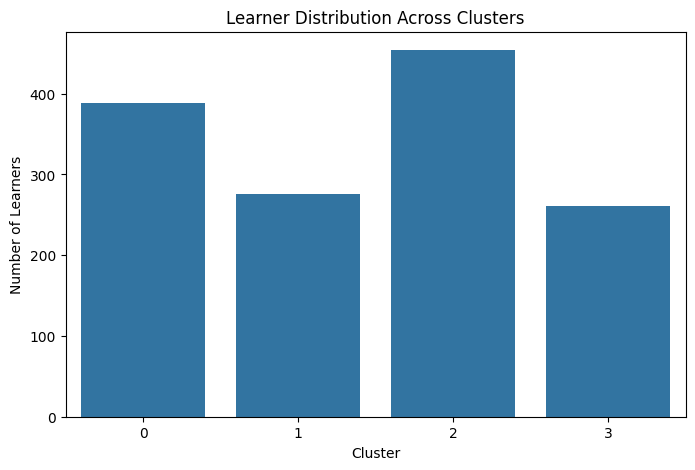

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cluster",
    data=learner_profile
)

plt.title("Learner Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Learners")

plt.show()

**Cluster Analysis**

In [ ]:
cluster_summary = (
    learner_profile
    .groupby("Cluster")
    [
        [
            "TotalCourses",
            "AvgSpending",
            "EnrollmentFrequency",
            "DiversityScore",
            "AvgRating",
            "LearningDepthIndex"
        ]
    ]
    .mean()
)
print(cluster_summary)

         TotalCourses  AvgSpending  EnrollmentFrequency  DiversityScore  \
Cluster                                                                   
0            2.424165    43.041352             2.424165        2.282776   
1            2.601449    32.263892             2.601449        2.394928   
2           13.405286    93.243348            13.405286        8.731278   
3            2.425287   205.669339             2.425287        2.295019   

         AvgRating  LearningDepthIndex  
Cluster                                 
0         3.039072            2.066838  
1         3.442192            0.514432  
2         3.114229            1.091967  
3         3.026973            0.861239  


**PCA Visualization**

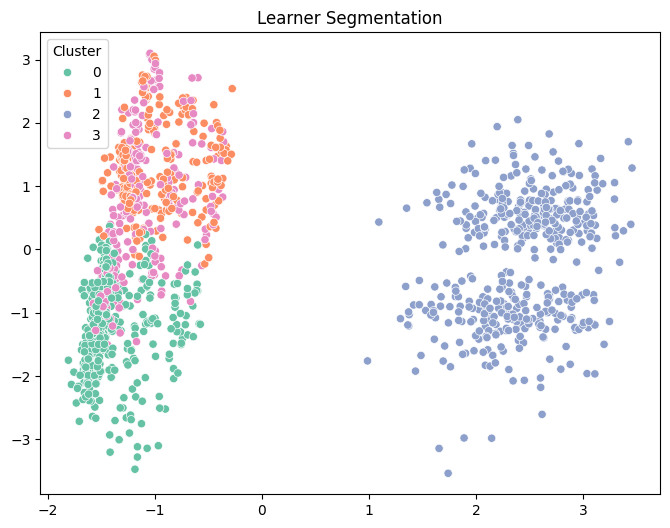

In [ ]:
pca = PCA(n_components=2)

components = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=components[:,0],
    y=components[:,1],
    hue=learner_profile["Cluster"],
    palette="Set2"
)

plt.title("Learner Segmentation")

plt.show()

**Save Segments**

In [ ]:
learner_profile["Cluster"] = (
    kmeans.fit_predict(X_scaled)
)

learner_profile.to_csv(
    "Student_Segments.csv",
    index=False
)
print("Segmentation Completed")

Segmentation Completed


**Personalized Recommendation Logic**

**Content-based filtering**

In [ ]:
def recommend_courses(user_id, top_n=5):

    user_cluster = learner_profile[
        learner_profile["UserID"] == user_id
    ]["Cluster"].values[0]

    cluster_users = learner_profile[
        learner_profile["Cluster"] == user_cluster
    ]["UserID"]

    cluster_data = data[
        data["UserID"].isin(cluster_users)
    ]

    recommendations = (
        cluster_data.groupby(
            ["CourseID","CourseCategory"]
        )
        .agg({
            "CourseRating":"mean"
        })
        .reset_index()
        .sort_values(
            "CourseRating",
            ascending=False
        )
    )

    enrolled = data[
        data["UserID"] == user_id
    ]["CourseID"]

    recommendations = recommendations[
        ~recommendations["CourseID"].isin(
            enrolled
        )
    ]

    return recommendations.head(top_n)

**Similar learner profiles**

In [ ]:
similarity_matrix = cosine_similarity(
    X_scaled
)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=learner_profile["UserID"],
    columns=learner_profile["UserID"]
)
def similar_learners(user_id, top_n=5):

    sims = similarity_df.loc[user_id]

    sims = sims.sort_values(
        ascending=False
    )

    return sims.iloc[1:top_n+1]

**Course popularity within cluster**

In [ ]:
cluster_course_popularity = (
    student_data.merge(
        learner_profile[
            ["UserID","Cluster"]
        ],
        on="UserID"
    )
)

popular_courses = (
    cluster_course_popularity
    .groupby(
        ["Cluster","CourseID"]
    )
    .size()
    .reset_index(
        name="Enrollments"
    )
)
top_cluster_courses = (
    popular_courses
    .sort_values(
        ["Cluster","Enrollments"],
        ascending=False
    )
)

**Rating-weighted relevance**

In [ ]:
course_scores = (
    student_data.groupby(
        "CourseID"
    )
    .agg({
        "CourseRating":"mean",
        "CourseID":"count"
    })
)

course_scores.columns = [
    "AvgRating",
    "Popularity"
]
course_scores["WeightedScore"] = (
    course_scores["AvgRating"] * 0.7
    +
    course_scores["Popularity"] * 0.3
)
course_scores = course_scores.sort_values(
    "WeightedScore",
    ascending=False
)

In [ ]:
import pickle

# Save model
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
#Save encoders
encoders = {
    "gender": le_gender,
    "category": le_category,
    "level": le_level
}
with open("label_encoder.pkl","wb") as f:
    pickle.dump(encoders,f)

In [ ]:
# KMeans
with open("kmeans_model.pkl", "rb") as f:
    kmeans = pickle.load(f)

# Scaler
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Label Encoders
with open("label_encoder.pkl", "rb") as f:
    encoders = pickle.load(f)

le_gender = encoders["gender"]
le_category = encoders["category"]
le_level = encoders["level"]

In [ ]:
segments = pd.read_csv("Student_Segments.csv")
print(segments.head())
print(segments.columns.tolist())


   UserID  TotalCourses  AvgSpending  DiversityScore  AvgRating  \
0  U00003            11    55.816364               7   2.889091   
1  U00004            13    75.542308               8   3.451538   
2  U00005             2   173.355000               2   2.055000   
3  U00010             2   163.010000               2   3.165000   
4  U00011             2   149.785000               2   3.205000   

   EnrollmentFrequency        UserName  Age  Gender  \
0                   11  morrisonamanda   33       0   
1                   13       fthornton   23       0   
2                    2  fostergeoffrey   21       1   
3                    2            qlam   34       0   
4                    2        ashley16   15       0   

                              Email  CourseCategory  CourseLevel  \
0               ganderson@yahoo.com               8            0   
1  christensencatherine@outlook.com               5            2   
2            karenfuentes@yahoo.com               9           